# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import Huber
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from datetime import datetime

# Data Understanding

In [2]:
df = pd.read_csv('/content/DataProduksi.csv')
df

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,Jan-09,1427.10,50.00,8.80
1,Feb-09,1188.00,45.50,7.90
2,Mar-09,1346.70,40.10,8.50
3,Apr-09,1193.50,38.80,9.30
4,May-09,1239.50,47.20,10.30
...,...,...,...,...
115,Aug-18,2075.95,35.32,5.99
116,Sep-18,2093.69,49.37,6.78
117,Oct-18,2075.70,51.21,8.12
118,Nov-18,1931.94,48.77,8.48


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tanggal       120 non-null    object 
 1   Minyak Sawit  120 non-null    float64
 2   Karet Kering  120 non-null    float64
 3   Teh           120 non-null    float64
dtypes: float64(3), object(1)
memory usage: 3.9+ KB


# Preprocessing

## Change date format

In [4]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%b-%y').dt.strftime('%Y-%m')
df.head()

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,1427.1,50.0,8.8
1,2009-02,1188.0,45.5,7.9
2,2009-03,1346.7,40.1,8.5
3,2009-04,1193.5,38.8,9.3
4,2009-05,1239.5,47.2,10.3


## Normalization

In [5]:
scaler = MinMaxScaler()
columns = ['Minyak Sawit', 'Karet Kering', 'Teh']
df[columns] = scaler.fit_transform(df[columns])
df.head()

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,0.434536,0.351266,0.655963
1,2009-02,0.248938,0.268072,0.449541
2,2009-03,0.372127,0.168238,0.587156
3,2009-04,0.253208,0.144204,0.770642
4,2009-05,0.288915,0.299501,1.000000


## Separating DataFrame Columns into Separate Variables

In [6]:
dates = df['Tanggal'].values
minyak_sawit = df['Minyak Sawit'].values
karet_kering = df['Karet Kering'].values
teh = df['Teh'].values

## Windowed Dataset

In [7]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[-1:]))
    return ds.batch(batch_size).prefetch(1)

## Split Dataset

In [8]:
def split_data(data):
  time = np.array(range(len(data)))
  series = np.array(data)

  X_train, X_test, y_train, y_test = train_test_split(series, time,test_size=0.1, random_state=42)
  return X_train, X_test, y_train, y_test

# LSTM model

In [17]:
def model_lstm(data, attribute_name):
  X_train, X_test, y_train, y_test = split_data(data)
  model = Sequential([
    LSTM(60, return_sequences=True),
    LSTM(60),
    Dense(30, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="relu"),
    Dropout(0.2),
    Dense(1)])
  
  train_set = windowed_dataset(
      X_train, window_size=60,
      batch_size=100,
      shuffle_buffer=1000
  )

  valid_set = windowed_dataset(
      X_test, window_size=60,
      batch_size=100,
      shuffle_buffer=1000
  )
  
  optimizer = SGD(learning_rate=1.0000e-04, momentum=0.9)
  model.compile(loss=tf.keras.losses.Huber(),
                optimizer=optimizer,
                metrics=["mae"])

  history = model.fit(train_set, epochs=30,
                      validation_data=valid_set,
                      batch_size=128)
  
  y_pred = history.predict(X_test.reshape(-1,1))
  # mae = mean_absolute_error(y_test, y_pred)
  # r2 = r2_score(y_test, y_pred)
  # print('R2 Score:', r2)
  # print('MAE:', mae)

  plt.figure(figsize=(20, 5))
  plt.plot(y_test, label='Actual')
  plt.plot(y_pred, label='Predicted')
  plt.legend()
  plt.title(f'Data {attribute_name}')
  plt.xlabel('Bulan')
  plt.ylabel('Produksi')
  plt.xticks(rotation=45)
  plt.show()

  # plt.plot(history.history['loss'], label='Loss')
  # plt.plot(history.history['mae'], label='MAE')
  # plt.title(f'LSTM {attribute_name}')
  # plt.ylabel('Epoch')
  # plt.legend()
  # plt.show()

# SVR Model

In [10]:
def model_svr(data, attribute_name):
  X_train, X_test, y_train, y_test = split_data(data)
  svr = SVR()
  svr.fit(X_train.reshape(-1,1), y_train)
  y_pred = svr.predict(X_test.reshape(-1,1))

  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print('R2 Score:', r2)
  print('MAE:', mae)
  plt.figure(figsize=(20, 5))
  plt.plot(dates[len(X_train):], y_test, label='Data Test')
  plt.plot(dates[len(X_train):], y_pred, label='Prediksi')
  plt.legend()
  plt.title(f'Data {attribute_name}')
  plt.xlabel('Bulan')
  plt.ylabel('Produksi')
  plt.xticks(rotation=50)
  plt.show()

# LSTM Evaluation

## Minyak Sawit

In [18]:
model_lstm(minyak_sawit, 'Minyak Sawit')

Epoch 1/30
1/1 [==============================] - 8s 8s/step - loss: 0.1746 - mae: 0.5438
Epoch 2/30
1/1 [==============================] - 0s 132ms/step - loss: 0.1729 - mae: 0.5411
Epoch 3/30
1/1 [==============================] - 0s 177ms/step - loss: 0.1757 - mae: 0.5467
Epoch 4/30
1/1 [==============================] - 0s 205ms/step - loss: 0.1773 - mae: 0.5495
Epoch 5/30
1/1 [==============================] - 0s 182ms/step - loss: 0.1738 - mae: 0.5463
Epoch 6/30
1/1 [==============================] - 0s 179ms/step - loss: 0.1750 - mae: 0.5489
Epoch 7/30
1/1 [==============================] - 0s 189ms/step - loss: 0.1727 - mae: 0.5422
Epoch 8/30
1/1 [==============================] - 0s 204ms/step - loss: 0.1690 - mae: 0.5352
Epoch 9/30
1/1 [==============================] - 0s 180ms/step - loss: 0.1724 - mae: 0.5431
Epoch 10/30
1/1 [==============================] - 0s 207ms/step - loss: 0.1719 - mae: 0.5379
Epoch 11/30
1/1 [==============================] - 0s 194ms/step - loss:

AttributeError: ignored

## Karet Kering

Epoch 1/30
1/1 [==============================] - 6s 6s/step - loss: 0.0814 - mae: 0.3244
Epoch 2/30
1/1 [==============================] - 0s 109ms/step - loss: 0.0812 - mae: 0.3220
Epoch 3/30
1/1 [==============================] - 0s 110ms/step - loss: 0.0812 - mae: 0.3239
Epoch 4/30
1/1 [==============================] - 0s 118ms/step - loss: 0.0795 - mae: 0.3210
Epoch 5/30
1/1 [==============================] - 0s 115ms/step - loss: 0.0807 - mae: 0.3190
Epoch 6/30
1/1 [==============================] - 0s 111ms/step - loss: 0.0794 - mae: 0.3225
Epoch 7/30
1/1 [==============================] - 0s 118ms/step - loss: 0.0806 - mae: 0.3235
Epoch 8/30
1/1 [==============================] - 0s 113ms/step - loss: 0.0776 - mae: 0.3110
Epoch 9/30
1/1 [==============================] - 0s 117ms/step - loss: 0.0798 - mae: 0.3209
Epoch 10/30
1/1 [==============================] - 0s 120ms/step - loss: 0.0801 - mae: 0.3205
Epoch 11/30
1/1 [==============================] - 0s 203ms/step - loss:

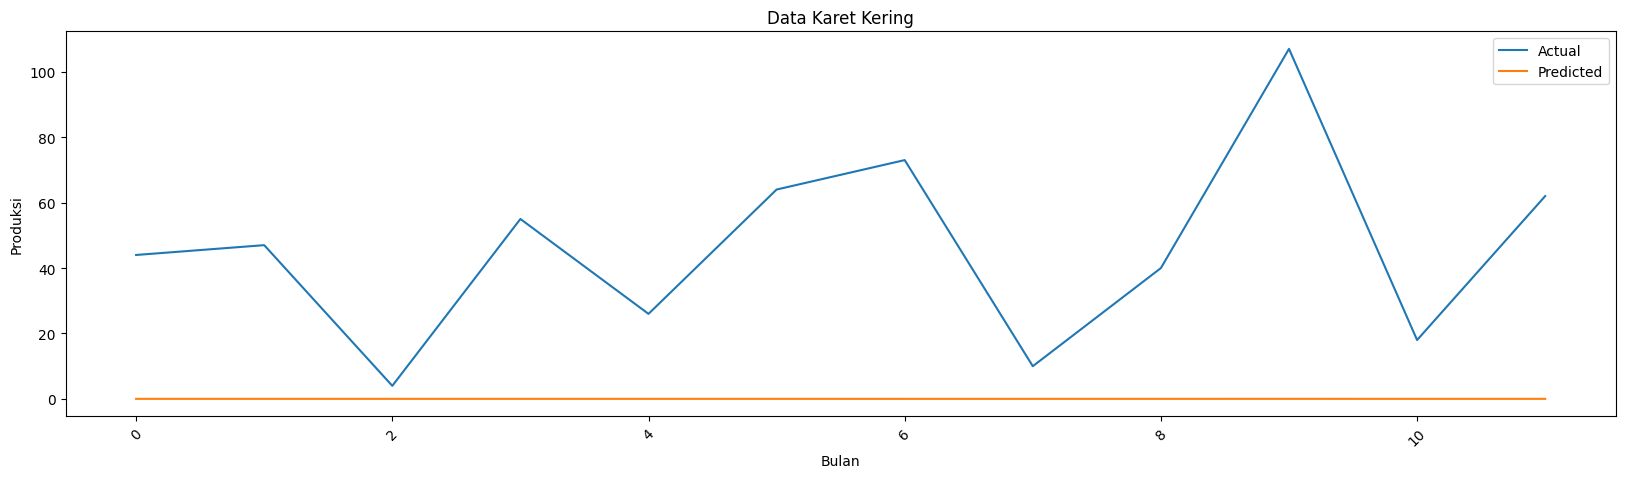

In [12]:
model_lstm(karet_kering, 'Karet Kering')

## Teh

Epoch 1/30
1/1 [==============================] - 6s 6s/step - loss: 0.1139 - mae: 0.4330
Epoch 2/30
1/1 [==============================] - 0s 123ms/step - loss: 0.1135 - mae: 0.4314
Epoch 3/30
1/1 [==============================] - 0s 114ms/step - loss: 0.1146 - mae: 0.4335
Epoch 4/30
1/1 [==============================] - 0s 120ms/step - loss: 0.1145 - mae: 0.4344
Epoch 5/30
1/1 [==============================] - 0s 117ms/step - loss: 0.1141 - mae: 0.4327
Epoch 6/30
1/1 [==============================] - 0s 148ms/step - loss: 0.1140 - mae: 0.4325
Epoch 7/30
1/1 [==============================] - 0s 186ms/step - loss: 0.1139 - mae: 0.4339
Epoch 8/30
1/1 [==============================] - 0s 181ms/step - loss: 0.1140 - mae: 0.4325
Epoch 9/30
1/1 [==============================] - 0s 188ms/step - loss: 0.1135 - mae: 0.4319
Epoch 10/30
1/1 [==============================] - 0s 189ms/step - loss: 0.1130 - mae: 0.4314
Epoch 11/30
1/1 [==============================] - 0s 223ms/step - loss:

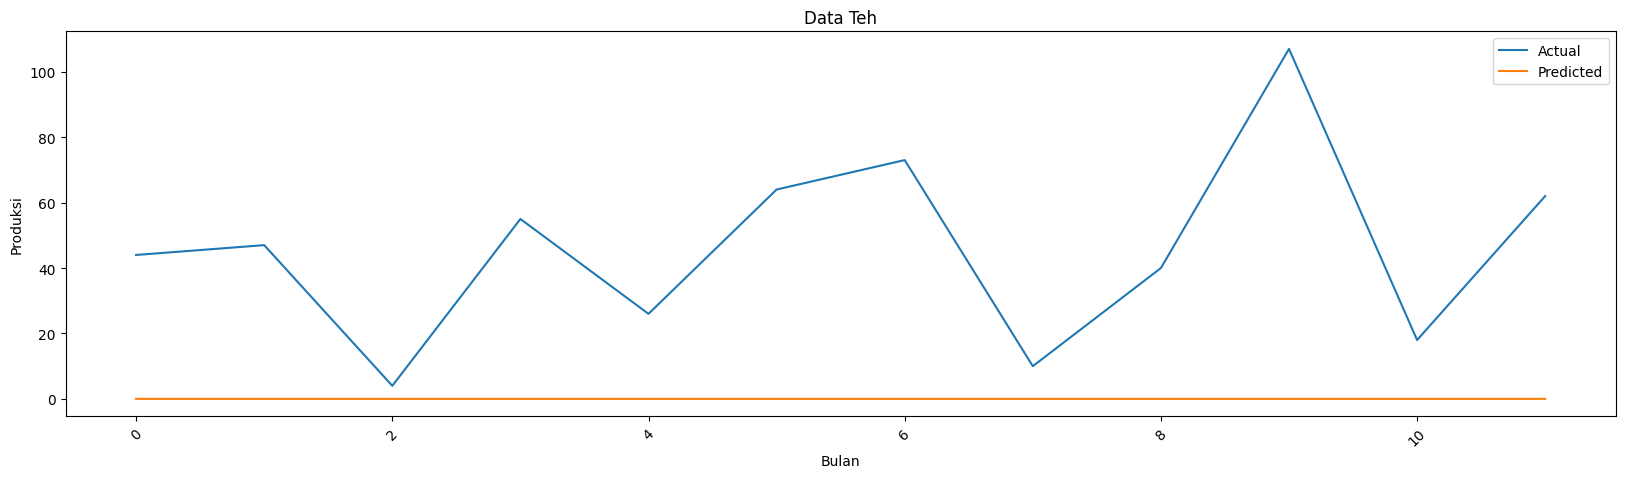

In [13]:
model_lstm(teh, 'Teh')

# SVR Evaluation

## Minyak Sawit

R2 Score: 0.4048470466841436
MAE: 17.646590969124187


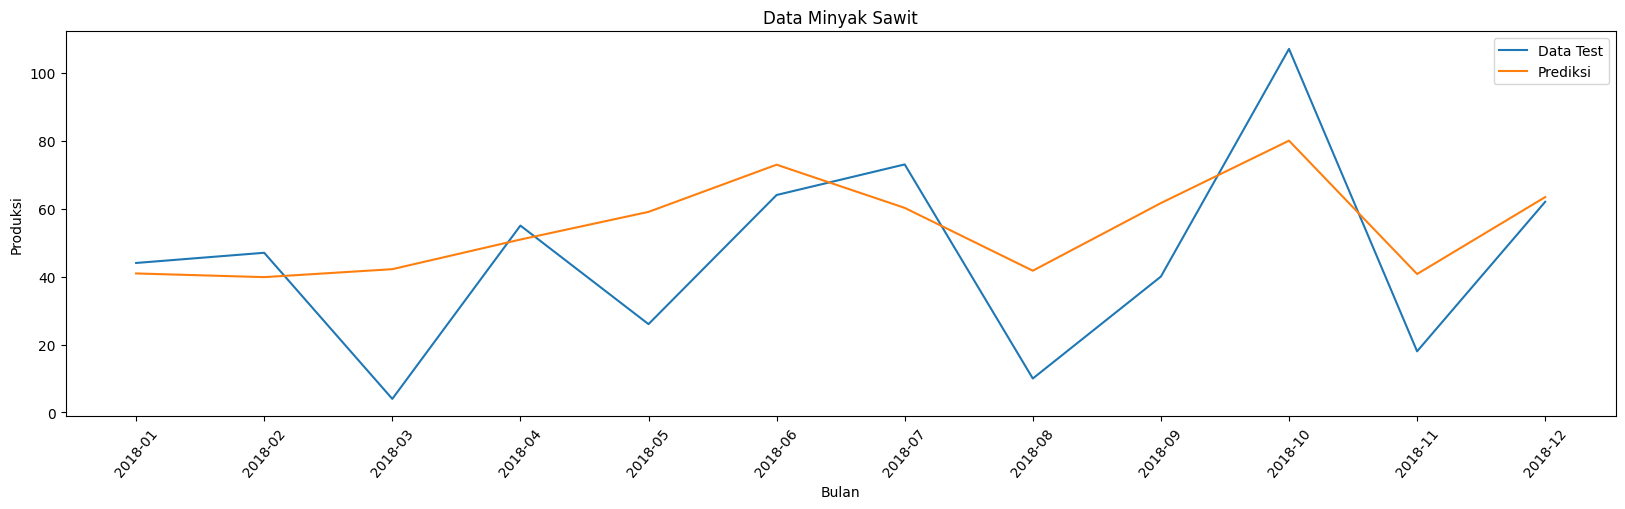

In [14]:
model_svr(minyak_sawit, 'Minyak Sawit')

## Karet Kering

R2 Score: -0.17334054150913447
MAE: 23.680693143519566


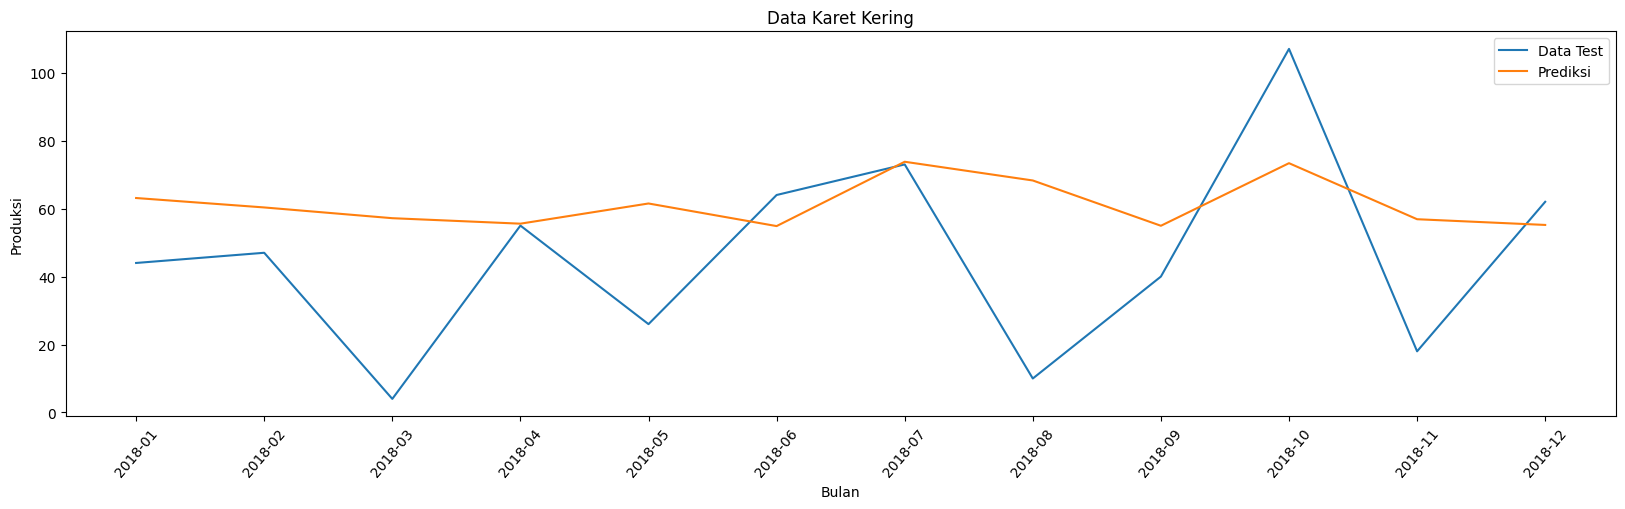

In [15]:
model_svr(karet_kering, 'Karet Kering')

## Teh

R2 Score: -0.3995101898420881
MAE: 26.610913340255085


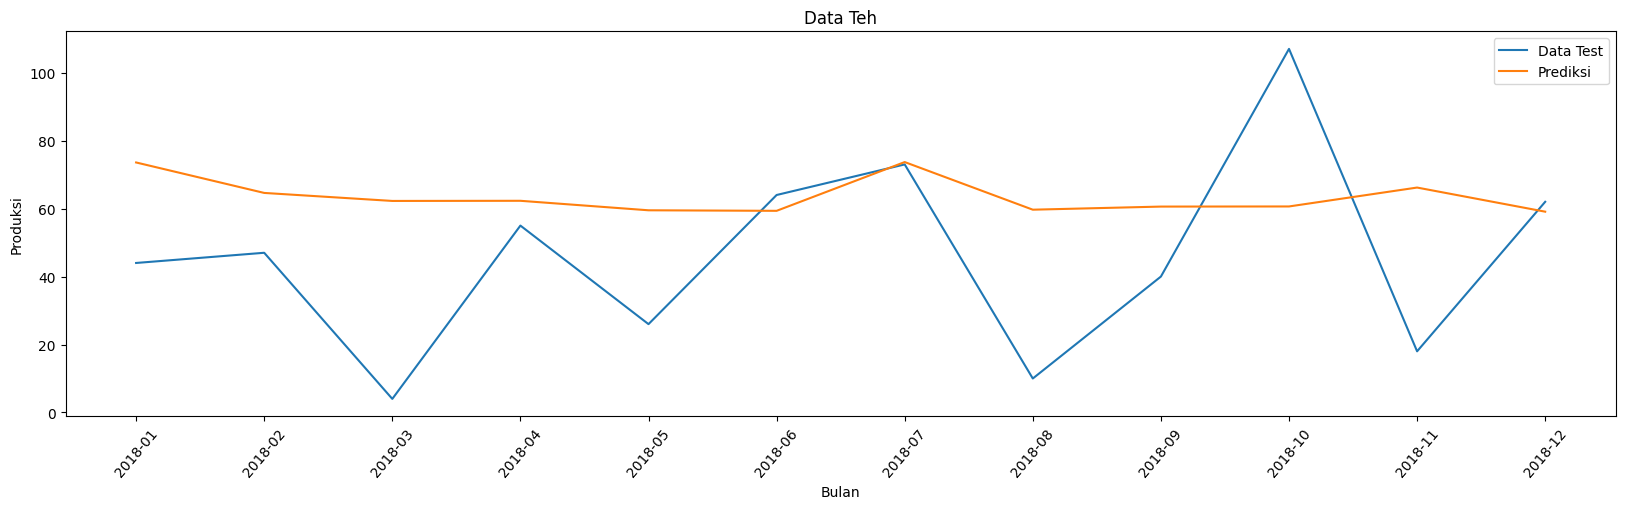

In [16]:
model_svr(teh, 'Teh')